In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

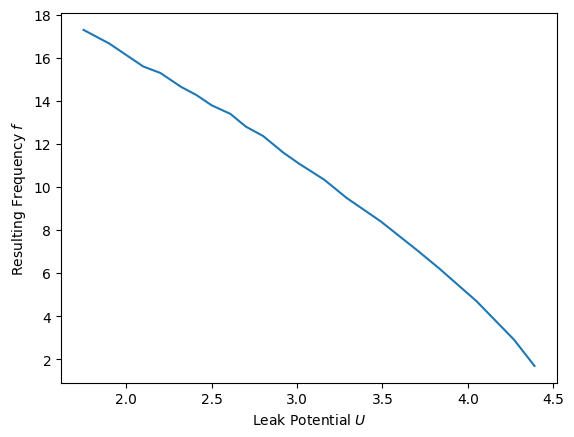

In [ ]:
pot, pot_error, freq, freq_error = np.loadtxt("freq_vs_current.txt", skiprows=1, delimiter=",").T

plt.plot(pot, freq)
plt.xlabel("Leak Potential $U$")
plt.ylabel("Resulting Frequency $f$")
plt.show()

Derive an equation for $f_{theo}(I)$. Your function should depend on the chosen parametrization of the LIF equation,
namely $ϑ$, $C_m$, $R$, and $τ_{ref}$. Here $R$ is the membrane resistance of the Lu.i. board, the inverse of the membrane
conductance, and $C_m$ is the membrane capacitance. You might need to define your integration limits. (Hint 1:
Consult equation (1.2) as a starting point; hint 2: You’ll find $R \cdot I > ϑ$ as a condition)

Fit the function to your measurements. You might find it helpful to extract the membrane capacitance value from
the circuit diagram.

$$
\tau_{mem} = RC \\
f_{theo}(I) = \frac{1}{T(I)} \\
T(I) = \tau_{ref} + t_{charge} \\
\text{We want to find the time it takes to charge the capacitor to } \vartheta \\
\tau_{mem} \cdot \frac{d u_i}{dt}(t) = − [u_i(t) − u_{rest}] + R \cdot I(t) \\
I(t) \text{ is constant in this experiment} \\
\frac{d u_i}{dt}(t) = (− [u_i(t) − u_{rest}] + R I) \cdot \frac{1}{\tau_{mem}} \\
u_i(t) = u_{rest} + RI(1 - e^{-\frac{t}{\tau_{mem}}}) \\
\vartheta = u_i(t) \\
\frac{\vartheta - u_{rest}}{RI} = 1 - e^{-\frac{t}{\tau_{mem}}} \\
e^{-\frac{t}{\tau_{mem}}} = 1 - \frac{\vartheta - u_{rest}}{RI} \\
t_{charge} = - \tau_{mem} \ln (1 - \frac{\vartheta - u_{rest}}{RI}) \\
t_{charge} = \tau_{mem} \ln (\frac{RI}{RI - \vartheta}) \\
f_{theo}(I) = (\tau_{ref} + \tau_{mem} \ln (\frac{RI}{RI - \vartheta}))^{-1}
$$

In [3]:
def freq_from_I_fitfunc(I, tau_ref, C, R, theta):
    t_charge = R * C * np.log(R * I / (R * I - theta))
    return 1/(tau_ref + t_charge)

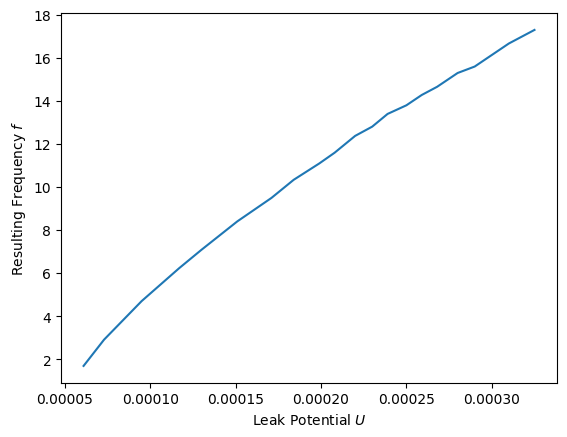

In [7]:
V_CC = 5    # V
R_sense = 10000    # Ohm
I = (V_CC - pot)/R_sense

plt.plot(I, freq)
plt.xlabel("Leak Potential $U$")
plt.ylabel("Resulting Frequency $f$")
plt.show()

In [6]:
p0 = [
    12.6* 10**-3,
    0.000001,
    10000,
    1.2
]

popt, pcov = curve_fit(
    freq_from_I_fitfunc,
    I,
    freq,
    p0 = p0
    #sigma
    #absolute_sigma = True
)

print(popt)
print(pcov)

[ 1.39930773e-02  6.74428620e-02  5.19779213e+08 -5.09850887e+04]
[[inf inf inf inf]
 [inf inf inf inf]
 [inf inf inf inf]
 [inf inf inf inf]]


/var/folders/lh/p9mw7lvd7bx4lm61ckr44rd80000gn/T/ipykernel_34354/121846996.py:8: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(
